# 📈 Tesla Stock Price Forecasting Using LSTM

**Portfolio Project — PyTorch + CUDA + Time-Series Forecasting**

This notebook is the condensed, presentation-ready version of the project.

### Objective
Use the previous **60 trading days of Tesla closing prices** to forecast the **next trading day's closing price**.

### Important
This is an **educational machine-learning forecasting project**, not financial advice. Stock prices are affected by many external variables and are inherently difficult to predict.

### What this version improves
- Keeps the important time-series reasoning.
- Removes repetitive inspection/plot/metric cells.
- Uses a strict chronological train/validation/test split.
- Fits preprocessing only on training data.
- Keeps the naive persistence baseline.
- Uses controlled experiments rather than random tuning.
- Adds a targeted **delta-target experiment** to test whether predicting price change is easier than predicting absolute price.
- Selects the final model using validation data and evaluates the test set only once.
- Includes final inference, model saving, reproducibility notes, and presentation-ready conclusions.

In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")

PyTorch: 2.7.1+cu128
Device: cuda
GPU: NVIDIA GeForce GTX 1650
CUDA: 12.8


## 1. Problem Formulation
 
For each trading day (t):
 
$$
X_t = [Close_{t-59}, \ldots, Close_t]
$$
 
and the model predicts:
 
$$
\hat{y}_{t+1} = Close_{t+1}
$$
 
The primary model therefore performs **one-step-ahead forecasting**.
 
### WHY DO WE CARE?
 
A time-series model must respect temporal order. Information from the future cannot be allowed to influence training or preprocessing.

In [2]:
# Download Tesla daily data

import yfinance as yf

df = yf.download(
    "TSLA",
    period="max",
    interval="1d",
    auto_adjust=False,
    progress=False
)

# Handle yfinance MultiIndex columns
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.index = pd.to_datetime(df.index)
df = df.sort_index()

required = ["Open", "High", "Low", "Close", "Volume"]

missing = [c for c in required if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[required].copy()

# Remove duplicate dates and missing rows
df = df[~df.index.duplicated(keep="first")]
df = df.dropna()

# Basic integrity checks
assert df.index.is_monotonic_increasing
assert (df["High"] >= df["Low"]).all()
assert (df["High"] >= df["Open"]).all()
assert (df["High"] >= df["Close"]).all()
assert (df["Low"] <= df["Open"]).all()
assert (df["Low"] <= df["Close"]).all()
assert (df["Close"] > 0).all()

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"Missing values: {df.isna().sum().sum()}")

display(df.tail())

Shape: (4094, 5)
Date range: 2010-06-29 → 2026-10-07
Missing values: 0


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-10-01,356.809998,359.790009,353.799988,354.109985,31080800
2026-10-02,360.079987,374.600006,359.410004,370.589996,55330100
2026-10-05,369.000000,381.589996,364.910004,378.730011,42232700
2026-10-06,381.980011,383.329987,378.519989,380.679993,27671400
2026-10-07,378.350006,382.349915,374.429993,376.850006,16553403


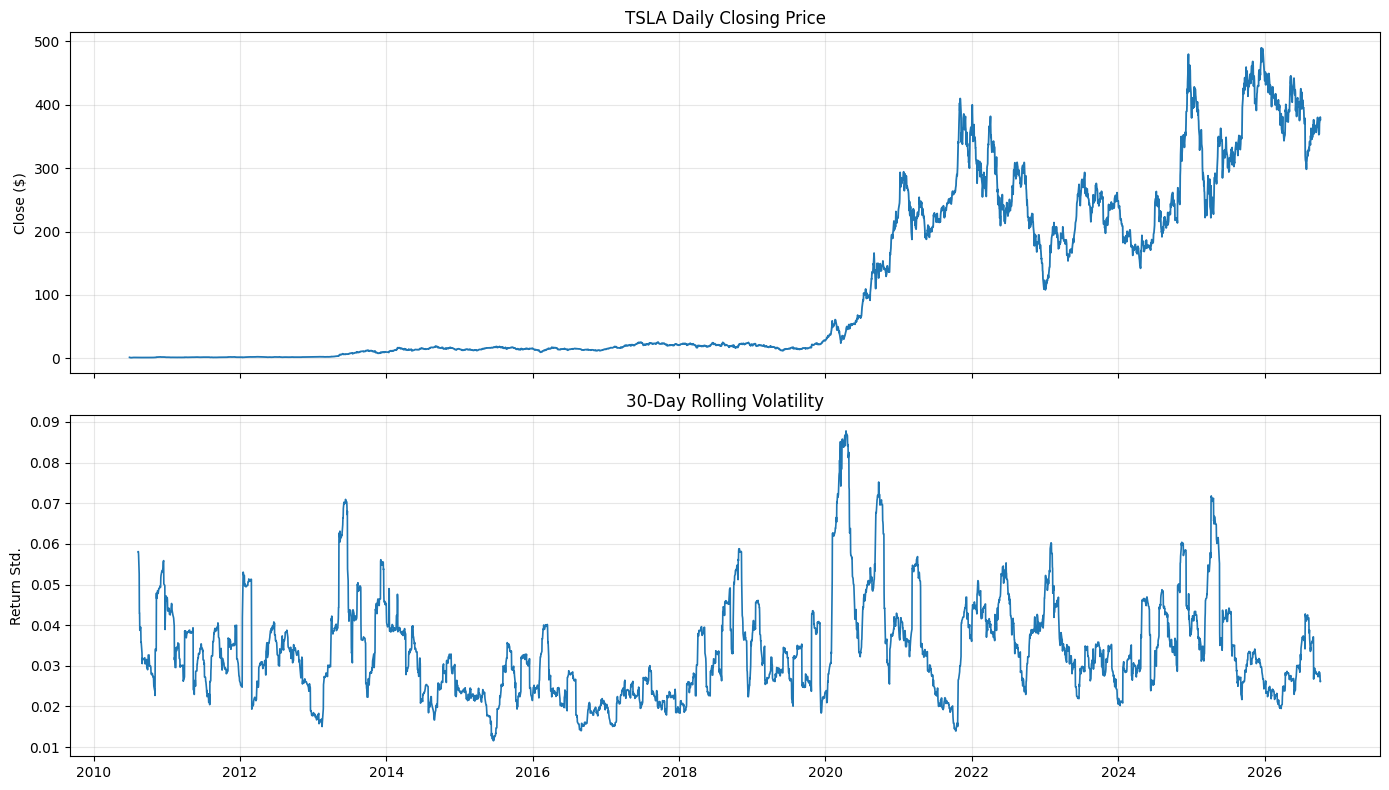

Daily return summary:


count    4093.000000
mean        0.001983
std         0.036076
min        -0.210628
25%        -0.016538
50%         0.001185
75%         0.019566
max         0.243951
Name: Daily_Return, dtype: float64

Key observation: the raw price is strongly non-stationary, while returns are much closer to a stable statistical representation.


In [3]:
# Compact EDA: price trend + returns/volatility
df["Daily_Return"] = df["Close"].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df["Close"], linewidth=1.3)
axes[0].set_title("TSLA Daily Closing Price")
axes[0].set_ylabel("Close ($)")
axes[0].grid(alpha=0.3)

rolling_vol = df["Daily_Return"].rolling(30).std()
axes[1].plot(df.index, rolling_vol, linewidth=1.2)
axes[1].set_title("30-Day Rolling Volatility")
axes[1].set_ylabel("Return Std.")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Daily return summary:")
display(df["Daily_Return"].describe())

print("Key observation: the raw price is strongly non-stationary, while returns are much closer to a stable statistical representation.")

## 2. Chronological Split + Leakage-Free Scaling

We create the next-day target first, then split chronologically:

**Earlier → Train | Later → Validation | Latest → Test**

The scaler is fitted **only on training Close values**.

### WHY DO WE CARE?
Fitting a scaler on validation/test information lets future information influence the representation learned during training. That is temporal leakage.

In [4]:
# One-step-ahead target
model_df = df.copy()
model_df["Target_Close"] = model_df["Close"].shift(-1)
model_df = model_df.dropna(subset=["Target_Close"]).copy()

# Chronological 80 / 10 / 10 split
n = len(model_df)
train_end = int(n * 0.80)
val_end = int(n * 0.90)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

print("TRAIN :", train_df.index.min().date(), "→", train_df.index.max().date(), len(train_df))
print("VAL   :", val_df.index.min().date(), "→", val_df.index.max().date(), len(val_df))
print("TEST  :", test_df.index.min().date(), "→", test_df.index.max().date(), len(test_df))

assert train_df.index.max() < val_df.index.min()
assert val_df.index.max() < test_df.index.min()

# Fit only on training Close
close_scaler = StandardScaler()
close_scaler.fit(train_df[["Close"]])

for split in (train_df, val_df, test_df):
    split["Close_scaled"] = close_scaler.transform(split[["Close"]].to_numpy()).ravel()

# Targets use the SAME training-fitted price scaler
for split in (train_df, val_df, test_df):
    split["Target_scaled"] = close_scaler.transform(
        split[["Target_Close"]].to_numpy()
    ).ravel()

print(f"Training scaler mean: {close_scaler.mean_[0]:.4f}")
print(f"Training scaler std : {close_scaler.scale_[0]:.4f}")

TRAIN : 2010-06-29 → 2023-06-30 3274
VAL   : 2023-07-03 → 2025-02-18 409
TEST  : 2025-02-19 → 2026-10-06 410
Training scaler mean: 63.6704
Training scaler std : 97.0931


## 3. Sliding Windows
 
We use a **60-trading-day lookback**.

 
Earlier experiments already established that 30 days was worse than 60 days on validation.

 
For the close model:
 
$$
X.shape = [samples,\ 60,\ 1]
$$
 
$$
y.shape = [samples]
$$
 
Validation/test windows receive historical context from the immediately preceding split. That is legitimate historical information, not future leakage.

In [5]:
SEQUENCE_LENGTH = 60
BATCH_SIZE = 64

def create_sequences(features, targets, sequence_length):
    X, y = [], []

    for i in range(sequence_length, len(features)):
        X.append(features[i-sequence_length:i])
        y.append(targets[i])

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)


def make_split_sequences(current_df, context_df=None, target_column="Target_scaled"):
    if context_df is not None:
        feature_series = pd.concat([
            context_df[["Close_scaled"]].tail(SEQUENCE_LENGTH),
            current_df[["Close_scaled"]]
        ])
        target_series = pd.concat([
            context_df[[target_column]].tail(SEQUENCE_LENGTH),
            current_df[[target_column]]
        ])
    else:
        feature_series = current_df[["Close_scaled"]]
        target_series = current_df[[target_column]]

    X, y = create_sequences(
        feature_series.values,
        target_series.values.ravel(),
        SEQUENCE_LENGTH
    )

    return X, y


X_train, y_train = make_split_sequences(train_df)
X_val, y_val = make_split_sequences(val_df, train_df)
X_test, y_test = make_split_sequences(test_df, val_df)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

assert X_train.shape[1:] == (60, 1)
assert X_val.shape[1:] == (60, 1)
assert X_test.shape[1:] == (60, 1)

X_train: (3214, 60, 1) y_train: (3214,)
X_val  : (409, 60, 1) y_val  : (409,)
X_test : (410, 60, 1) y_test : (410,)


In [6]:
def make_loader(X, y, shuffle):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        pin_memory=(device.type == "cuda")
    )

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val, shuffle=False)
test_loader = make_loader(X_test, y_test, shuffle=False)

X_batch, y_batch = next(iter(train_loader))

print("Batch X:", X_batch.shape, X_batch.dtype)
print("Batch y:", y_batch.shape, y_batch.dtype)
print("Training batches:", len(train_loader))

assert X_batch.shape == (min(BATCH_SIZE, len(X_train)), 60, 1)

Batch X: torch.Size([64, 60, 1]) torch.float32
Batch y: torch.Size([64]) torch.float32
Training batches: 51


## 4. Naive Persistence Baseline
 
The baseline predicts:
 
$$
\hat{P}_{t+1} = P_t
$$
 
This is deliberately simple, but it is a strong baseline for short-horizon stock-price forecasting.
 
### WHY DO WE CARE?
 
A complex LSTM is useful only if it adds predictive value beyond a simple strategy.
``

In [7]:
def inverse_close(values):
    values = np.asarray(values).reshape(-1, 1)
    return close_scaler.inverse_transform(values).ravel()

# Validation naive prediction = current day's Close
val_current_close = val_df["Close"].values

val_naive_predictions = val_current_close.copy()
val_actual = val_df["Target_Close"].values

val_naive_mae = mean_absolute_error(val_actual, val_naive_predictions)
val_naive_mse = mean_squared_error(val_actual, val_naive_predictions)
val_naive_rmse = np.sqrt(val_naive_mse)

print(f"Validation Naive MAE : ${val_naive_mae:.4f}")
print(f"Validation Naive RMSE: ${val_naive_rmse:.4f}")

Validation Naive MAE : $6.6291
Validation Naive RMSE: $9.5392


## 5. LSTM + Controlled Experiment Framework
 
Rather than maintaining many repetitive training cells, one reusable training function runs the meaningful candidates.
 
We keep the strongest configuration found previously (**60 days, Close, 128 hidden units, 2 layers, dropout 0.2**) and test two focused alternatives:
 
1. **Huber/SmoothL1 loss**: potentially more robust to extreme errors.
2. **Delta target**: predict $Close_{t+1} - Close_t$, then reconstruct the next price.
 
The validation set decides which candidate survives. The test set remains untouched until the final evaluation.

In [8]:
class TeslaLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.lstm(x)
        output = output[:, -1, :]
        return self.fc(output).squeeze(-1)


def train_model(model, train_loader, val_loader, criterion,
                epochs=50, lr=1e-3, patience=7):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_state = None
    best_val_loss = float("inf")
    history = []
    wait = 0

    model.to(device)

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(
                device_type=device.type,
                enabled=use_amp
            ):
                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device, non_blocking=True)
                y_batch = y_batch.to(device, non_blocking=True)

                with torch.amp.autocast(
                    device_type=device.type,
                    enabled=use_amp
                ):
                    predictions = model(X_batch)
                    loss = criterion(predictions, y_batch)

                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))

        scheduler.step(val_loss)
        history.append((epoch, train_loss, val_loss))

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    return model, history, best_val_loss


def predict_loader(model, loader):
    model.eval()
    predictions, actuals = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)

            with torch.amp.autocast(
                device_type=device.type,
                enabled=(device.type == "cuda")
            ):
                pred = model(X_batch)

            predictions.append(pred.float().cpu().numpy())
            actuals.append(y_batch.numpy())

    return np.concatenate(predictions), np.concatenate(actuals)

In [9]:
def metric_row(name, actual, predicted, best_val_loss):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)

    return {
        "Model": name,
        "Validation MAE ($)": mae,
        "Validation RMSE ($)": rmse,
        "Best Val Loss": best_val_loss
    }


def make_delta_sequences(split_df, context_df=None):
    # Delta target: next close - current close
    temp = split_df.copy()
    temp["Delta"] = temp["Target_Close"] - temp["Close"]

    if context_df is not None:
        context = context_df.copy()
        context["Delta"] = context["Target_Close"] - context["Close"]

        features = pd.concat([
            context[["Close_scaled"]].tail(SEQUENCE_LENGTH),
            temp[["Close_scaled"]]
        ])

        targets = pd.concat([
            context[["Delta_scaled"]].tail(SEQUENCE_LENGTH),
            temp[["Delta_scaled"]]
        ])
    else:
        features = temp[["Close_scaled"]]
        targets = temp[["Delta_scaled"]]

    X, delta = create_sequences(
        features.values,
        targets.values.ravel(),
        SEQUENCE_LENGTH
    )

    return X, delta


# Delta scaler is fitted ONLY on training deltas
train_delta = train_df["Target_Close"] - train_df["Close"]
delta_scaler = StandardScaler()
delta_scaler.fit(train_delta.values.reshape(-1, 1))

train_df["Delta_scaled"] = delta_scaler.transform(
    train_delta.values.reshape(-1, 1)
).ravel()

for split in (val_df, test_df):
    delta = split["Target_Close"] - split["Close"]
    split["Delta_scaled"] = delta_scaler.transform(
        delta.values.reshape(-1, 1)
    ).ravel()

X_train_delta, y_train_delta = make_delta_sequences(train_df)
X_val_delta, y_val_delta = make_delta_sequences(val_df, train_df)

train_delta_loader = make_loader(X_train_delta, y_train_delta, shuffle=True)
val_delta_loader = make_loader(X_val_delta, y_val_delta, shuffle=False)

print("Delta experiment shapes:")
print("Train:", X_train_delta.shape, y_train_delta.shape)
print("Val  :", X_val_delta.shape, y_val_delta.shape)

Delta experiment shapes:
Train: (3214, 60, 1) (3214,)
Val  : (409, 60, 1) (409,)


In [10]:
# ============================================================
# CONTROLLED EXPERIMENTS
# ============================================================
# The same split, sequence length, optimizer and training budget
# are used. Only the intended variable changes.

experiments = []

# Experiment A — established best configuration
torch.manual_seed(SEED)
model_mse = TeslaLSTM(hidden_size=128, num_layers=2, dropout=0.2)

model_mse, hist_mse, loss_mse = train_model(
    model_mse,
    train_loader,
    val_loader,
    nn.MSELoss(),
    epochs=50,
    lr=1e-3
)

pred_scaled, _ = predict_loader(model_mse, val_loader)
pred_close = inverse_close(pred_scaled)

experiments.append(
    metric_row("Close + MSE (128)", val_actual, pred_close, loss_mse)
)

# Experiment B — robust loss
torch.manual_seed(SEED)
model_huber = TeslaLSTM(hidden_size=128, num_layers=2, dropout=0.2)

model_huber, hist_huber, loss_huber = train_model(
    model_huber,
    train_loader,
    val_loader,
    nn.SmoothL1Loss(beta=0.5),
    epochs=50,
    lr=1e-3
)

pred_scaled_huber, _ = predict_loader(model_huber, val_loader)
pred_close_huber = inverse_close(pred_scaled_huber)

experiments.append(
    metric_row("Close + Huber (128)", val_actual, pred_close_huber, loss_huber)
)

# Experiment C — predict next-day price change
torch.manual_seed(SEED)
model_delta = TeslaLSTM(hidden_size=128, num_layers=2, dropout=0.2)

model_delta, hist_delta, loss_delta = train_model(
    model_delta,
    train_delta_loader,
    val_delta_loader,
    nn.MSELoss(),
    epochs=50,
    lr=1e-3
)

delta_scaled_pred, _ = predict_loader(model_delta, val_delta_loader)
delta_pred = delta_scaler.inverse_transform(
    delta_scaled_pred.reshape(-1, 1)
).ravel()

# For every validation target, current close is the final observed
# value in its 60-day input window.
current_close_for_val = val_df["Close"].values
delta_pred_close = current_close_for_val + delta_pred

experiments.append(
    metric_row("Delta + MSE (128)", val_actual, delta_pred_close, loss_delta)
)

experiment_table = (
    pd.DataFrame(experiments)
    .sort_values("Validation MAE ($)")
    .reset_index(drop=True)
)

display(experiment_table)

,Model,Validation MAE ($),Validation RMSE ($),Best Val Loss
0,Delta + MSE (128),6.621399,9.531174,4.673742
1,Close + Huber (128),10.801361,15.429949,0.025947
2,Close + MSE (128),11.296791,15.389723,0.025353


### Experiment decision

The selection rule is simple:

> **Choose the model with the lowest validation MAE.**

This keeps model selection separate from the final test evaluation.

Earlier experiments already found:
- 30-day sequence < 60-day sequence
- OHLCV features < Close-only
- 128 hidden units > 64
- 2 LSTM layers > 3
- dropout 0.2 > 0.4
- learning rate 0.001 > 0.0005

In [11]:
# Select the validation winner: Delta + MSE
final_model = model_delta.to(device)
final_history = hist_delta

print("Selected final model: Delta + MSE (128)")
print("Target representation: Next-day price change (Delta)")

# Validation predictions
final_val_scaled, _ = predict_loader(
    final_model,
    val_delta_loader
)

# Convert predicted scaled delta back to dollar values
final_delta = delta_scaler.inverse_transform(
    final_val_scaled.reshape(-1, 1)
).ravel()

# Reconstruct predicted next-day Close
final_val_predictions = (
    val_df["Close"].values + final_delta
)

# Actual next-day Close
final_val_actual = val_actual

# Final validation metrics
final_val_mae = mean_absolute_error(
    final_val_actual,
    final_val_predictions
)

final_val_rmse = np.sqrt(
    mean_squared_error(
        final_val_actual,
        final_val_predictions
    )
)

print(f"Final validation MAE  : ${final_val_mae:.4f}")
print(f"Final validation RMSE : ${final_val_rmse:.4f}")
print(f"Naive validation MAE  : ${val_naive_mae:.4f}")

Selected final model: Delta + MSE (128)
Target representation: Next-day price change (Delta)
Final validation MAE  : $6.6214
Final validation RMSE : $9.5312
Naive validation MAE  : $6.6291


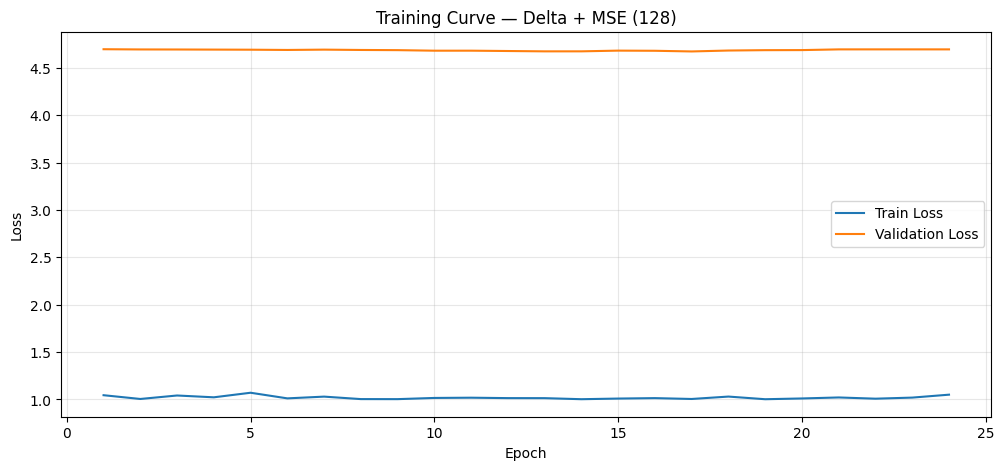

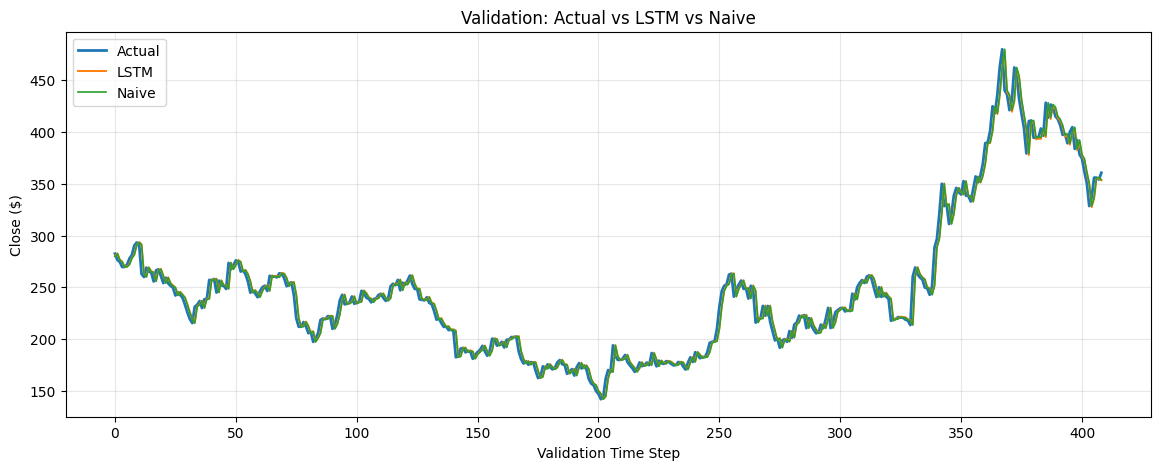

In [12]:
# Validation learning curve
history_df = pd.DataFrame(
    final_history,
    columns=["Epoch", "Train_Loss", "Val_Loss"]
)

plt.figure(figsize=(12, 5))
plt.plot(history_df["Epoch"], history_df["Train_Loss"], label="Train Loss")
plt.plot(history_df["Epoch"], history_df["Val_Loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training Curve — Delta + MSE (128)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Validation forecast behaviour
plt.figure(figsize=(14, 5))
plt.plot(final_val_actual, label="Actual", linewidth=2)
plt.plot(final_val_predictions, label="LSTM", linewidth=1.4)
plt.plot(val_naive_predictions, label="Naive", linewidth=1.2)
plt.title("Validation: Actual vs LSTM vs Naive")
plt.xlabel("Validation Time Step")
plt.ylabel("Close ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Final Unseen Test Evaluation

The test set has not been used to choose the architecture, loss, sequence length, or hyperparameters.

Now we evaluate the selected model once.

### WHY DO WE CARE?
This is the closest estimate in the project of how the chosen pipeline generalizes to genuinely later data.

In [13]:
# Final test predictions — Delta + MSE
# The test set is used only after model selection.

# Create delta test sequences using validation data as historical context
X_test_delta, y_test_delta = make_delta_sequences(
    test_df,
    val_df
)

test_delta_loader = make_loader(
    X_test_delta,
    y_test_delta,
    shuffle=False
)

# Predict next-day delta
test_delta_scaled, _ = predict_loader(
    final_model,
    test_delta_loader
)

# Convert predicted delta back to dollar values
test_delta = delta_scaler.inverse_transform(
    test_delta_scaled.reshape(-1, 1)
).ravel()

# Reconstruct predicted next-day Close
test_predictions = (
    test_df["Close"].values + test_delta
)

# Actual next-day Close
test_actual = test_df["Target_Close"].values

# Naive baseline: tomorrow's price = today's price
test_naive_predictions = test_df["Close"].values

# Final LSTM metrics
final_test_mae = mean_absolute_error(
    test_actual,
    test_predictions
)

final_test_mse = mean_squared_error(
    test_actual,
    test_predictions
)

final_test_rmse = np.sqrt(final_test_mse)

# Naive baseline metrics
test_naive_mae = mean_absolute_error(
    test_actual,
    test_naive_predictions
)

test_naive_mse = mean_squared_error(
    test_actual,
    test_naive_predictions
)

test_naive_rmse = np.sqrt(test_naive_mse)

# Compare final LSTM with naive baseline
final_test_results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Final LSTM"
    ],
    "MAE ($)": [
        test_naive_mae,
        final_test_mae
    ],
    "MSE": [
        test_naive_mse,
        final_test_mse
    ],
    "RMSE ($)": [
        test_naive_rmse,
        final_test_rmse
    ]
})

display(final_test_results)

print(
    f"Final LSTM vs naive MAE change: "
    f"{((final_test_mae / test_naive_mae) - 1) * 100:+.1f}%"
)

,Model,MAE ($),MSE,RMSE ($)
0,Naive Baseline,9.187635,145.903643,12.079058
1,Final LSTM,9.227254,145.789799,12.074345


Final LSTM vs naive MAE change: +0.4%


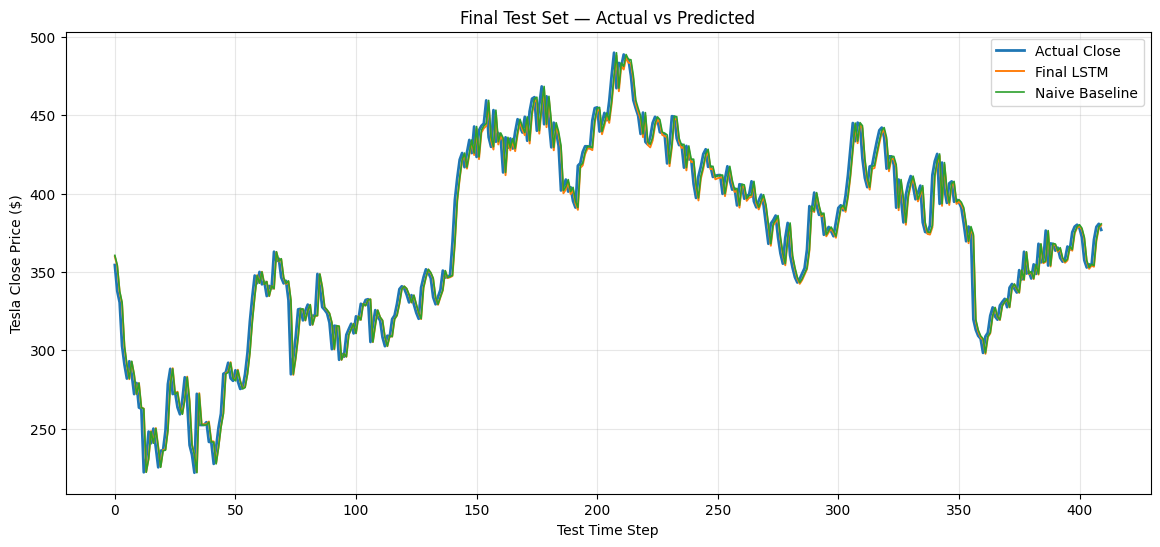

In [14]:
# Final test forecast visualization
plt.figure(figsize=(14, 6))

plt.plot(test_actual, label="Actual Close", linewidth=2)
plt.plot(test_predictions, label="Final LSTM", linewidth=1.4)
plt.plot(test_naive_predictions, label="Naive Baseline", linewidth=1.2)

plt.title("Final Test Set — Actual vs Predicted")
plt.xlabel("Test Time Step")
plt.ylabel("Tesla Close Price ($)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Test error summary:


count    410.000000
mean       0.875493
std       12.057275
min      -53.158728
25%       -5.780566
50%        1.185998
75%        9.242139
max       49.912199
Name: Error, dtype: float64

Largest LSTM test errors:


,Actual,LSTM_Predicted,Naive_Predicted,Error,Absolute_Error
356,319.690002,372.848731,374.010010,-53.158728,53.158728
34,272.200012,222.287814,221.860001,49.912199,49.912199
73,284.700012,331.642442,332.049988,-46.942429,46.942429
12,222.149994,262.785760,262.670013,-40.635766,40.635766
339,411.839996,378.501120,379.709991,33.338876,33.338876
342,393.450012,424.068980,425.299988,-30.618968,30.618968
22,278.390015,249.168257,248.710007,29.221758,29.221758
288,391.950012,363.525726,364.200012,28.424286,28.424286
31,239.429993,267.674054,267.279999,-28.244062,28.244062
192,417.779999,389.623240,391.089996,28.156759,28.156759


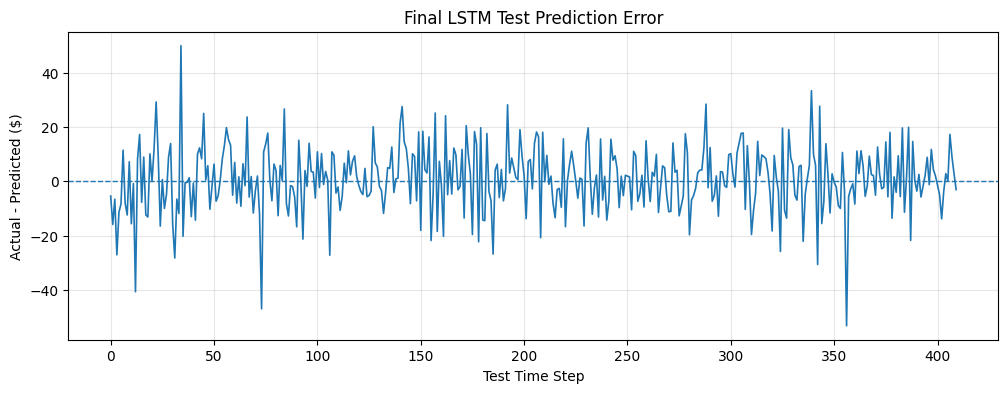

In [15]:
# Final test error analysis
test_errors = test_actual - test_predictions

test_error_df = pd.DataFrame({
    "Actual": test_actual,
    "LSTM_Predicted": test_predictions,
    "Naive_Predicted": test_naive_predictions,
    "Error": test_errors,
    "Absolute_Error": np.abs(test_errors)
})

print("Test error summary:")
display(test_error_df["Error"].describe())

print("Largest LSTM test errors:")
display(
    test_error_df
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 4))
plt.plot(test_errors, linewidth=1.2)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Final LSTM Test Prediction Error")
plt.xlabel("Test Time Step")
plt.ylabel("Actual - Predicted ($)")
plt.grid(alpha=0.3)
plt.show()

## 7. One-Step Inference

For deployment-style inference, the model receives the **latest 60 available trading days** and predicts the next trading day's close.

The prediction is a model output, **not a guaranteed future market price**.

In [16]:
# One-step forecast from the latest available history

latest_close = df["Close"].iloc[-1]

latest_window = df[["Close"]].tail(SEQUENCE_LENGTH)

if len(latest_window) < SEQUENCE_LENGTH:
    raise ValueError(
        "Not enough historical observations for inference."
    )

# Scale the latest 60 days using the training scaler
latest_scaled = close_scaler.transform(
    latest_window
).astype(np.float32)

# Add batch dimension: (60, 1) → (1, 60, 1)
latest_tensor = torch.tensor(
    latest_scaled,
    dtype=torch.float32
).unsqueeze(0).to(device)

# Generate next-day Delta prediction
final_model.eval()

with torch.no_grad():
    with torch.amp.autocast(
        device_type=device.type,
        enabled=(device.type == "cuda")
    ):
        forecast_output = (
            final_model(latest_tensor)
            .float()
            .cpu()
            .numpy()
        )

# Convert predicted Delta back to dollars
forecast_delta = delta_scaler.inverse_transform(
    forecast_output.reshape(-1, 1)
)[0, 0]

# Reconstruct predicted next-day Close
next_day_forecast = latest_close + forecast_delta

# Display forecast
print(f"Latest available Close : ${latest_close:.2f}")
print(f"Forecast next Close     : ${next_day_forecast:.2f}")
print(f"Forecast change         : ${forecast_delta:+.2f}")

Latest available Close : $376.85
Forecast next Close     : $376.01
Forecast change         : $-0.84


In [17]:
# Save the final Delta + MSE model and preprocessing information

save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

checkpoint = {
    "model_state_dict": final_model.state_dict(),

    # Model configuration
    "model_name": "Delta + MSE (128)",
    "target_mode": "delta",
    "sequence_length": SEQUENCE_LENGTH,
    "hidden_size": 128,
    "num_layers": 2,
    "dropout": 0.2,
    "feature": "Close",

    # Close scaler
    "scaler_mean": close_scaler.mean_,
    "scaler_scale": close_scaler.scale_,

    # Delta scaler
    "delta_scaler_mean": delta_scaler.mean_,
    "delta_scaler_scale": delta_scaler.scale_,

    # Reproducibility
    "seed": SEED,
}

model_path = os.path.join(
    save_dir,
    "tesla_lstm_final.pt"
)

torch.save(checkpoint, model_path)

print(f"Final model saved: {model_path}")

Final model saved: models\tesla_lstm_final.pt
